In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib
from flask import Flask, request , jsonify


C:\Users\vivek\anaconda4\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("Iris.csv")  # replace with your path
df = df.drop(columns=["Id"])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
le = LabelEncoder()
y = le.fit_transform(df["Species"])  # 0,1,2
X = df.drop("Species", axis=1)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)        # transform test only

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

In [7]:
print("=== Cross-Validation Accuracy ===")
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    cv_results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f}")

=== Cross-Validation Accuracy ===
Logistic Regression: 0.9583
Decision Tree: 0.9417
Random Forest: 0.9500
XGBoost: 0.9500


In [8]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [200, 500]
}
grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv=5)
grid_lr.fit(X_train_scaled, y_train)
print("\nBest Logistic Regression params:", grid_lr.best_params_)
print("Best CV Accuracy:", grid_lr.best_score_)


Best Logistic Regression params: {'C': 10, 'max_iter': 200, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Accuracy: 0.9666666666666668



=== Final Test Set Evaluation (Logistic Regression) ===
Final Test Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



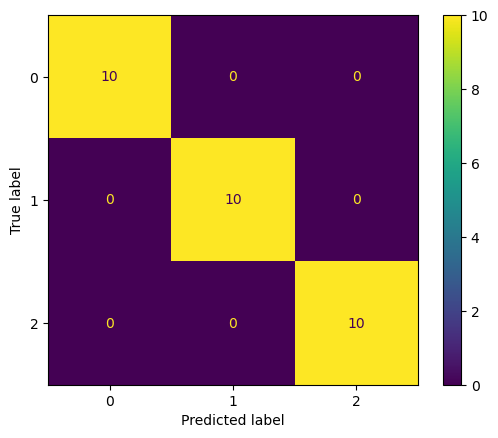

In [9]:
best_model = grid_lr.best_estimator_
final_preds = best_model.predict(X_test_scaled)

# Evaluate

print("\n=== Final Test Set Evaluation (Logistic Regression) ===")
print("Final Test Accuracy:", accuracy_score(y_test, final_preds))
print(classification_report(y_test, final_preds))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test)

In [10]:
coefficients = best_model.coef_
features = X.columns
classes = le.classes_

for i, class_name in enumerate(classes):
    print(f"\nClass {class_name} coefficients:")
    for feat, coef in zip(features, coefficients[i]):
        print(f"{feat}: {coef:.3f}")



Class Iris-setosa coefficients:
SepalLengthCm: -1.804
SepalWidthCm: 1.713
PetalLengthCm: -3.307
PetalWidthCm: -3.196

Class Iris-versicolor coefficients:
SepalLengthCm: 1.137
SepalWidthCm: -0.289
PetalLengthCm: -1.150
PetalWidthCm: -1.439

Class Iris-virginica coefficients:
SepalLengthCm: 0.668
SepalWidthCm: -1.424
PetalLengthCm: 4.457
PetalWidthCm: 4.634


In [11]:
joblib.dump(best_model,'final_lr_model.pkl')

['final_lr_model.pkl']

In [12]:
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [13]:
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [2]:
import requests

# Include the correct endpoint
url = "http://127.0.0.1:5000/predict"

data = [
    {"SepalLengthCm": 5.1, "SepalWidthCm": 3.5, "PetalLengthCm": 1.4, "PetalWidthCm": 0.2},
    {"SepalLengthCm": 6.3, "SepalWidthCm": 3.3, "PetalLengthCm": 6.0, "PetalWidthCm": 2.5},
    {"SepalLengthCm": 5.9, "SepalWidthCm": 3.0, "PetalLengthCm": 5.1, "PetalWidthCm": 1.8},
    {"SepalLengthCm": 6.0,"SepalWidthCm": 2.9,"PetalLengthCm": 4.5,"PetalWidthCm": 1.5 }
]

response = requests.post(url, json=data)

print(response.json())


['Iris-setosa', 'Iris-virginica', 'Iris-virginica', 'Iris-versicolor']


In [ ]:
"""
Logistic Regression Coefficient Interpretation for Iris Dataset

Class: Iris-setosa
------------------
SepalLengthCm: -1.804  → Longer sepals decrease the probability of being setosa.
SepalWidthCm:  1.713  → Wider sepals increase the probability of being setosa.
PetalLengthCm: -3.307 → Longer petals strongly decrease the probability of being setosa.
PetalWidthCm:  -3.196 → Wider petals strongly decrease the probability of being setosa.

Interpretation:
Iris-setosa is characterized by small petal size and moderately wide sepals.
Petal size is the most distinguishing feature for this class.

Class: Iris-versicolor
----------------------
SepalLengthCm:  1.137 → Longer sepals slightly increase the probability of being versicolor.
SepalWidthCm:  -0.289 → Slightly narrower sepals favor versicolor.
PetalLengthCm: -1.150 → Longer petals decrease the probability of being versicolor.
PetalWidthCm:  -1.439 → Wider petals decrease the probability of being versicolor.

Interpretation:
Iris-versicolor has medium-sized petals. Very long petals push predictions toward virginica.
Sepal dimensions have less impact compared to petal dimensions.

Class: Iris-virginica
---------------------
SepalLengthCm:  0.668 → Longer sepals slightly increase the probability of being virginica.
SepalWidthCm:  -1.424 → Narrower sepals increase the probability of being virginica.
PetalLengthCm:  4.457 → Very long petals strongly increase the probability of being virginica.
PetalWidthCm:   4.630 → Wide petals strongly increase the probability of being virginica.

Interpretation:
Iris-virginica is distinguished by very large petals, which is the strongest signal for this class.
Sepal width has some influence, but petal size dominates.

Overall Insights
----------------
1. Petal dimensions are the most important features for class separation:
   - Small petals → setosa
   - Medium petals → versicolor
   - Large petals → virginica

2. Sepal dimensions have secondary importance:
   - Wider sepals → setosa
   - Narrower sepals → virginica

3. Sign of coefficients indicates direction:
   - Positive → feature increases probability of that class
   - Negative → feature decreases probability of that class

4. Magnitude of coefficients indicates strength of influence:
   - PetalLength and PetalWidth have the largest absolute values → most discriminative features.
"""
